
# Laboratorio TDM — Compressione audio percettiva (dal PCM al MP3)

**Obiettivo della lezione:** capire perché e come si comprime un segnale audio, collegando tre idee:

1. **quantizzazione** (quanti bit uso per ogni campione, e quanto rumore introduco),
2. **mascheramento psicoacustico** (quali componenti spettrali sono davvero udibili),
3. **codifica reale** (cosa succede quando esporto in MP3 a bitrate diversi).

Questa lezione prosegue le precedenti su campionamento/Nyquist, FFT/spettro e filtri: qui useremo di nuovo FFT e filtraggio, ma per **decidere cosa scartare** invece che solo per analizzare o ripulire il segnale.

Il notebook è organizzato in 3 coding lab indipendenti (puoi eseguirli in ordine) più una pipeline finale che li unisce.



## API tour — le librerie che useremo oggi

Prima di scrivere codice, ecco una mappa delle API principali: cosa fanno e con quali argomenti le useremo. Non serve impararle a memoria: torna qui ogni volta che una funzione non ti è chiara.

| Libreria / funzione | Cosa fa | Argomenti che useremo oggi |
|---|---|---|
| `numpy` (`np`) | Libreria per calcolo numerico su array. La usiamo per generare segnali, applicare formule (quantizzazione, SNR) e manipolare campioni audio come vettori. | `np.linspace(start, stop, num)` per assi temporali; `np.sin`; `np.round`; operazioni vettoriali (`+`, `*`, `**`). |
| `scipy.io.wavfile.read(path)` / `.write(path, rate, data)` | Legge/scrive file `.wav` **non compressi** (PCM). `read` restituisce `(sample_rate, array_campioni)`; `write` richiede `sample_rate` e un array (tipicamente `int16`). | `path`: percorso file; `rate`: frequenza di campionamento in Hz; `data`: array numpy dei campioni. |
| `scipy.signal.stft(x, fs, nperseg)` | Calcola la **Short-Time Fourier Transform**: divide il segnale in finestre sovrapposte e calcola la FFT di ciascuna, dando un'immagine tempo-frequenza (lo spettrogramma complesso). | `x`: segnale; `fs`: sample rate; `nperseg`: lunghezza di ogni finestra (più lunga = più risoluzione in frequenza, meno in tempo). Restituisce `(f, t, Zxx)`: frequenze, istanti temporali, matrice complessa. |
| `scipy.signal.istft(Zxx, fs, nperseg)` | Operazione inversa: ricostruisce il segnale nel tempo a partire dallo spettrogramma complesso (eventualmente modificato). | `Zxx`: matrice tempo-frequenza; stessi `fs`/`nperseg` usati nella STFT diretta, altrimenti la ricostruzione è sbagliata. |
| `matplotlib.pyplot` (`plt`) | Libreria di plotting. La usiamo per disegnare forme d'onda, spettri e spettrogrammi. | `plt.plot`, `plt.pcolormesh` (per spettrogrammi), `plt.xlabel/ylabel/title/legend`. |
| `IPython.display.Audio(data, rate)` | Crea un **player audio interattivo** dentro il notebook, senza bisogno di casse collegate al server: basta un browser. | `data`: array numpy dei campioni (float in [-1,1] oppure int16); `rate`: sample rate in Hz. |
| `pydub.AudioSegment` | Wrapper Python su **ffmpeg**: permette di leggere/scrivere formati compressi come MP3 senza scrivere a mano il bitstream. | `AudioSegment.from_wav(path)` per leggere un wav; `.export(path, format="mp3", bitrate="128k")` per codificare con un bitrate scelto; `.get_array_of_samples()` per tornare a un array numpy dopo la decodifica. |
| `os.path.getsize(path)` | Restituisce la dimensione di un file in byte. La usiamo per confrontare quanto "pesa" l'audio a bitrate diversi. | `path`: percorso del file. |

> Nota: se un giorno esegui questo notebook fuori da Jupyter (es. come script `.py`), sostituisci `IPython.display.Audio` con `sounddevice.play(data, samplerate)` per sentire l'audio dagli altoparlanti locali.


In [1]:

# Import di tutte le librerie che useremo nel notebook.
import os
import tempfile

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import stft, istft
from IPython.display import Audio, display
from pydub import AudioSegment

# Cartella temporanea dove scriveremo i file wav/mp3 intermedi.
TMPDIR = tempfile.mkdtemp(prefix="tdm_audio_lab_")
print("Cartella temporanea:", TMPDIR)

# Stile grafici (puramente estetico)
plt.rcParams["figure.figsize"] = (9, 3)


Cartella temporanea: /var/folders/31/bfd9d07j4qb8xsmvzx9q67ww0000gn/T/tdm_audio_lab_rd8bosvt



## 0. Segnale di test

Per non dipendere da un file audio esterno, generiamo un segnale sintetico che assomiglia a un semplice suono musicale: tre toni puri sovrapposti (accordo) più un po' di rumore, con un breve inviluppo di ampiezza (attacco/decadimento) per renderlo meno "artificiale".

**Se hai un tuo file `.wav` mono**, puoi sostituire questa cella con:
```python
sr, signal_int = wavfile.read("mio_file.wav")
signal = signal_int.astype(np.float32) / np.iinfo(signal_int.dtype).max
```
e assicurarti che `signal` sia un array float normalizzato in `[-1, 1]`.


Numero di campioni: 88200  | durata: 2.0 s


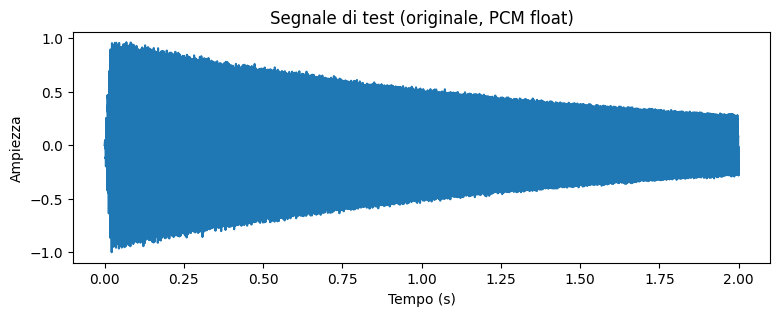

In [2]:

SR = 44100          # sample rate in Hz (standard qualità CD)
DURATION = 2.0       # durata del segnale di test, in secondi

def generate_test_signal(duration=DURATION, sr=SR, seed=0):
    '''Genera un segnale sintetico: accordo di 3 toni + rumore + inviluppo.

    Parametri
    ---------
    duration : float
        durata in secondi.
    sr : int
        sample rate in Hz.
    seed : int
        seme per il generatore di rumore (riproducibilità).

    Ritorna
    -------
    t : np.ndarray
        asse dei tempi (secondi).
    signal : np.ndarray
        campioni audio, float32, normalizzati in [-1, 1].
    '''
    rng = np.random.default_rng(seed)
    t = np.linspace(0, duration, int(sr * duration), endpoint=False)

    freqs = [220.0, 440.0, 880.0]        # un accordo semplice (La, La ottava sopra, ecc.)
    amps = [0.5, 0.3, 0.2]
    tone = sum(a * np.sin(2 * np.pi * f * t) for f, a in zip(freqs, amps))

    noise = 0.02 * rng.standard_normal(len(t))   # rumore di fondo, ampiezza piccola

    # inviluppo: attacco rapido + decadimento esponenziale, per evitare click
    envelope = np.minimum(1.0, t / 0.02) * np.exp(-t / (duration * 0.8))

    signal = (tone + noise) * envelope
    signal = signal / np.max(np.abs(signal))     # normalizza a [-1, 1]
    return t, signal.astype(np.float32)

t, signal = generate_test_signal()
print("Numero di campioni:", len(signal), " | durata:", len(signal) / SR, "s")

plt.plot(t, signal)
plt.xlabel("Tempo (s)")
plt.ylabel("Ampiezza")
plt.title("Segnale di test (originale, PCM float)")
plt.show()

display(Audio(signal, rate=SR))



## Lab 1 — Quantizzazione: quanti bit servono davvero?

**Richiamo teorico.** Ogni campione PCM viene arrotondato a uno dei $2^{B}$ livelli disponibili, dove $B$ è il numero di bit. Meno bit significa passo di quantizzazione più grande, quindi più **rumore di quantizzazione**. Il rapporto segnale/rumore (SNR) di un quantizzatore uniforme a $B$ bit è approssimativamente:

$$\text{SNR}_{dB} \approx 6.02 \cdot B + 1.76$$

Verifichiamolo sperimentalmente: ri-quantizziamo il nostro segnale a 16, 8, 4 e 2 bit, misuriamo l'SNR reale e ascoltiamo la differenza.


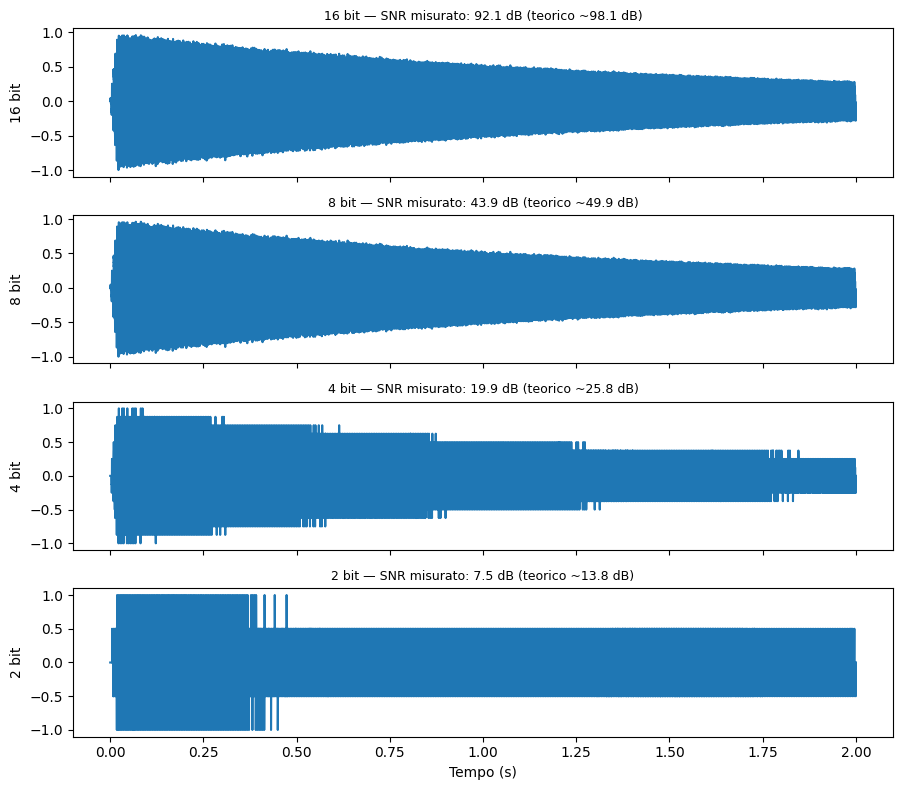

In [3]:

def quantize(sig, bits):
    '''Ri-quantizza un segnale float in [-1, 1] a un numero di bit ridotto.

    Parametri
    ---------
    sig : np.ndarray
        segnale originale, float, valori attesi in [-1, 1].
    bits : int
        numero di bit del quantizzatore uniforme (es. 8, 4, 2).

    Ritorna
    -------
    np.ndarray
        segnale quantizzato, stesso range, stessa lunghezza.
    '''
    levels = 2 ** bits
    step = 2.0 / levels                       # passo di quantizzazione su [-1, 1]
    q = np.round(sig / step) * step           # np.round arrotonda al livello più vicino
    return np.clip(q, -1.0, 1.0)              # evita overflow numerico ai bordi


def snr_db(original, processed):
    '''Calcola l'SNR in dB tra segnale originale e segnale processato.

    SNR_dB = 10 * log10( energia_segnale / energia_rumore )
    dove il "rumore" e' semplicemente la differenza campione per campione.
    '''
    noise = original - processed
    signal_power = np.sum(original ** 2)
    noise_power = np.sum(noise ** 2) + 1e-12   # evita divisione per zero
    return 10 * np.log10(signal_power / noise_power)


bit_depths = [16, 8, 4, 2]
quantized_signals = {}

fig, axes = plt.subplots(len(bit_depths), 1, figsize=(9, 8), sharex=True)
for ax, bits in zip(axes, bit_depths):
    q = quantize(signal, bits)
    quantized_signals[bits] = q
    measured_snr = snr_db(signal, q)
    theoretical_snr = 6.02 * bits + 1.76
    ax.plot(t, q)
    ax.set_ylabel(f"{bits} bit")
    ax.set_title(f"{bits} bit — SNR misurato: {measured_snr:.1f} dB (teorico ~{theoretical_snr:.1f} dB)", fontsize=9)
axes[-1].set_xlabel("Tempo (s)")
plt.tight_layout()
plt.show()


In [4]:

# Ascolto comparativo: esegui ogni cella e confronta a orecchio.
print("Originale (float, equivalente a >16 bit):")
display(Audio(signal, rate=SR))

for bits in bit_depths:
    print(f"Quantizzato a {bits} bit:")
    display(Audio(quantized_signals[bits], rate=SR))


Originale (float, equivalente a >16 bit):


Quantizzato a 16 bit:


Quantizzato a 8 bit:


Quantizzato a 4 bit:


Quantizzato a 2 bit:



**Domanda di verifica (Lab 1):** a 4 e 2 bit il rumore di quantizzazione diventa chiaramente udibile come un "fruscio" o una distorsione grezza. È un rumore distribuito su **tutte** le frequenze, indipendentemente da cosa stia suonando: per questo la semplice riduzione dei bit non è un buon modo per comprimere l'audio in modo trasparente.



## Lab 2 — Mascheramento psicoacustico (semplificato)

**Richiamo teorico.** L'orecchio umano non percepisce allo stesso modo tutte le componenti spettrali presenti in un istante: una componente forte "maschera" (rende inudibili) le componenti più deboli vicine in frequenza. I codec percettivi (MP3, AAC, ...) sfruttano questo per **buttare via** le componenti mascherate senza perdita percepita.

Qui implementiamo una versione **molto semplificata**: per ogni finestra temporale, calcoliamo lo spettro con la STFT e azzeriamo tutte le componenti che sono più deboli di una soglia relativa al picco spettrale di quella finestra (in dB). Non è il modello psicoacustico reale di MP3 (che usa bande critiche e curve di mascheramento in frequenza/tempo), ma ne cattura l'idea centrale: **scartare selettivamente, non uniformemente**.


In [5]:

def spectral_mask(sig, sr, threshold_db=40.0, nperseg=1024):
    '''Applica un mascheramento spettrale semplificato.

    Per ogni finestra temporale (colonna della STFT), le componenti in
    frequenza più deboli di 'threshold_db' rispetto al picco della finestra
    vengono azzerate, poi il segnale viene ricostruito con la ISTFT.

    Parametri
    ---------
    sig : np.ndarray
        segnale nel tempo.
    sr : int
        sample rate in Hz.
    threshold_db : float
        soglia relativa al picco spettrale della finestra, in dB.
        Valori più bassi = soglia più vicina al picco = mascheramento più
        aggressivo (si scarta di più); valori più alti = soglia più permissiva
        (si scarta meno).
    nperseg : int
        lunghezza della finestra STFT (campioni).

    Ritorna
    -------
    x_rec : np.ndarray
        segnale ricostruito nel tempo.
    frac_discarded : float
        frazione di energia spettrale scartata (indicatore di quanto abbiamo compresso).
    (f, Zxx, Zxx_masked) : tuple
        frequenze e spettrogrammi (originale/mascherato), utili per i grafici.
    '''
    f, tt, Zxx = stft(sig, fs=sr, nperseg=nperseg)
    mag = np.abs(Zxx)
    phase = np.angle(Zxx)

    frame_peak = mag.max(axis=0, keepdims=True)               # picco per ogni finestra temporale
    threshold = frame_peak * (10 ** (-threshold_db / 20.0))    # soglia assoluta per finestra
    keep_mask = mag >= threshold

    mag_masked = mag * keep_mask
    Zxx_masked = mag_masked * np.exp(1j * phase)

    _, x_rec = istft(Zxx_masked, fs=sr, nperseg=nperseg)
    x_rec = x_rec[: len(sig)]   # ISTFT può restituire qualche campione in più/meno

    energy_total = np.sum(mag ** 2)
    energy_discarded = np.sum((mag * (~keep_mask)) ** 2)
    frac_discarded = energy_discarded / (energy_total + 1e-12)

    return x_rec, frac_discarded, (f, Zxx, Zxx_masked)


thresholds = [20.0, 40.0, 60.0]
masked_signals = {}

for th in thresholds:
    x_rec, frac, (f, Zxx, Zxx_masked) = spectral_mask(signal, SR, threshold_db=th)
    masked_signals[th] = x_rec
    print(f"Soglia {th:>4.0f} dB -> energia spettrale scartata: {frac*100:5.1f}%  "
          f"| SNR rispetto all'originale: {snr_db(signal, x_rec):.1f} dB")


Soglia   20 dB -> energia spettrale scartata:   0.7%  | SNR rispetto all'originale: 23.8 dB
Soglia   40 dB -> energia spettrale scartata:   0.2%  | SNR rispetto all'originale: 26.9 dB
Soglia   60 dB -> energia spettrale scartata:   0.0%  | SNR rispetto all'originale: 52.5 dB


In [6]:

# Confronto visivo: spettrogramma originale vs. mascherato (soglia intermedia)
th_demo = 40.0
_, _, (f, Zxx, Zxx_masked) = spectral_mask(signal, SR, threshold_db=th_demo)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
mesh0 = axes[0].pcolormesh(np.arange(Zxx.shape[1]), f, 20 * np.log10(np.abs(Zxx) + 1e-6), shading="gouraud")
axes[0].set_title("Spettrogramma originale (dB)")
axes[0].set_ylabel("Frequenza (Hz)")
axes[0].set_xlabel("Finestra temporale")
fig.colorbar(mesh0, ax=axes[0], label="Livello (dB)")

mesh1 = axes[1].pcolormesh(np.arange(Zxx_masked.shape[1]), f, 20 * np.log10(np.abs(Zxx_masked) + 1e-6), shading="gouraud")
axes[1].set_title(f"Spettrogramma mascherato (soglia {th_demo:.0f} dB)")
axes[1].set_xlabel("Finestra temporale")
fig.colorbar(mesh1, ax=axes[1], label="Livello (dB)")

plt.tight_layout()
plt.show()

print("Originale:")
display(Audio(signal, rate=SR))
for th in thresholds:
    print(f"Mascherato a soglia {th:.0f} dB:")
    display(Audio(masked_signals[th], rate=SR))


Originale:


Mascherato a soglia 20 dB:


Mascherato a soglia 40 dB:


Mascherato a soglia 60 dB:



**Domanda di verifica (Lab 2):** confronta la percentuale di energia scartata (stampata sopra) con quanto la versione mascherata suona diversa dall'originale. A parità (circa) di "quanto materiale butti via", il mascheramento spettrale dovrebbe suonare **meglio** della quantizzazione grezza a pochi bit del Lab 1: perché?



## Lab 3 — Dal PCM al MP3: cosa succede con una codifica reale

Ora usiamo un encoder reale (MP3 via `ffmpeg`/`pydub`) invece del nostro modello giocattolo. Codifichiamo lo stesso segnale a bitrate decrescenti (320, 128, 64, 32 kbps), e confrontiamo dimensione del file, spettro e qualità percepita.

Ricorda dall'API tour: `AudioSegment.export(..., format="mp3", bitrate="128k")` chiama `ffmpeg` sotto il cofano; per confrontare servono sia il file compresso (per la dimensione) sia l'audio decodificato (per ascolto e spettro), perché MP3 è **lossy**: quello che riascolti non è bit-per-bit l'originale.


In [7]:

def encode_decode_mp3(sig, sr, bitrate_kbps, tmpdir=TMPDIR, tag=""):
    '''Codifica 'sig' in MP3 al bitrate dato e lo ridecodifica.

    Parametri
    ---------
    sig : np.ndarray
        segnale float in [-1, 1].
    sr : int
        sample rate in Hz.
    bitrate_kbps : int
        bitrate target per l'encoder MP3, in kbps (es. 128).
    tmpdir : str
        cartella dove scrivere i file temporanei wav/mp3.
    tag : str
        suffisso per distinguere i file temporanei.

    Ritorna
    -------
    decoded : np.ndarray
        segnale ricostruito dopo la decodifica MP3, float in [-1, 1].
    mp3_size_bytes : int
        dimensione del file mp3 risultante, in byte.
    '''
    wav_path = os.path.join(tmpdir, f"tmp_{tag}.wav")
    mp3_path = os.path.join(tmpdir, f"tmp_{tag}_{bitrate_kbps}k.mp3")

    # scipy.io.wavfile.write vuole interi; convertiamo da float [-1,1] a int16
    int16_sig = np.clip(sig, -1.0, 1.0)
    int16_sig = (int16_sig * 32767).astype(np.int16)
    wavfile.write(wav_path, sr, int16_sig)

    audio_seg = AudioSegment.from_wav(wav_path)
    audio_seg.export(mp3_path, format="mp3", bitrate=f"{bitrate_kbps}k")
    mp3_size_bytes = os.path.getsize(mp3_path)

    decoded_seg = AudioSegment.from_mp3(mp3_path)
    decoded_arr = np.array(decoded_seg.get_array_of_samples()).astype(np.float32)
    if decoded_seg.channels == 2:
        decoded_arr = decoded_arr.reshape(-1, 2).mean(axis=1)   # a mono se serve
    decoded_arr = decoded_arr / 32767.0

    # la decodifica MP3 può aggiungere qualche campione di "padding": allineiamo la lunghezza
    n = min(len(sig), len(decoded_arr))
    return decoded_arr[:n], mp3_size_bytes


bitrates = [320, 128, 64, 32]
mp3_results = {}

wav_reference_path = os.path.join(TMPDIR, "reference.wav")
wavfile.write(wav_reference_path, SR, (signal * 32767).astype(np.int16))
wav_size = os.path.getsize(wav_reference_path)
print(f"Dimensione WAV non compresso di riferimento: {wav_size/1024:.1f} KB")

for br in bitrates:
    decoded, size_bytes = encode_decode_mp3(signal, SR, br, tag=f"b{br}")
    mp3_results[br] = decoded
    ratio = wav_size / size_bytes
    print(f"MP3 @ {br:>3d} kbps -> {size_bytes/1024:6.1f} KB "
          f"(rapporto di compressione {ratio:4.1f}x) | SNR: {snr_db(signal[:len(decoded)], decoded):.1f} dB")


Dimensione WAV non compresso di riferimento: 172.3 KB


MP3 @ 320 kbps ->   80.7 KB (rapporto di compressione  2.1x) | SNR: 36.9 dB


MP3 @ 128 kbps ->   32.3 KB (rapporto di compressione  5.3x) | SNR: 25.5 dB


MP3 @  64 kbps ->   16.2 KB (rapporto di compressione 10.7x) | SNR: 23.4 dB
MP3 @  32 kbps ->    8.2 KB (rapporto di compressione 21.1x) | SNR: 20.2 dB


In [8]:

print("Originale:")
display(Audio(signal, rate=SR))
for br in bitrates:
    print(f"MP3 a {br} kbps:")
    display(Audio(mp3_results[br], rate=SR))


Originale:


MP3 a 320 kbps:


MP3 a 128 kbps:


MP3 a 64 kbps:


MP3 a 32 kbps:



**Domanda di verifica (Lab 3):** l'SNR misurato per l'MP3 a 320 kbps è spesso **peggiore in numero** di quello della quantizzazione a 8 bit del Lab 1, eppure a 320 kbps l'MP3 suona quasi indistinguibile dall'originale, mentre a 8 bit il rumore è ben udibile. Cosa ci dice questo sul limite dell'SNR come misura di qualità percepita, e perché il mascheramento psicoacustico del Lab 2 è più informativo?



## Pipeline finale — mettiamo insieme i pezzi

Costruiamo una mini "toy audio compressor" che incatena: mascheramento spettrale (Lab 2) → codifica MP3 a un bitrate scelto (Lab 3). È un esempio semplificato ma concettualmente vicino a cosa fa un encoder reale (analisi tempo-frequenza → decisioni percettive → codifica entropica finale, che qui sostituiamo con MP3 "chiavi in mano").


In [9]:

def toy_audio_compressor(sig, sr, mask_threshold_db=40.0, mp3_bitrate_kbps=64, tag="pipeline"):
    '''Pipeline dimostrativa: mascheramento spettrale + codifica MP3.

    Parametri
    ---------
    sig : np.ndarray
        segnale originale.
    sr : int
        sample rate.
    mask_threshold_db : float
        soglia di mascheramento spettrale (vedi Lab 2).
    mp3_bitrate_kbps : int
        bitrate per la codifica MP3 finale (vedi Lab 3).
    tag : str
        etichetta per i file temporanei.

    Ritorna
    -------
    dict con segnale intermedio (dopo mascheramento), segnale finale (dopo MP3),
    dimensione del file mp3 e SNR ai due stadi.
    '''
    masked, frac_discarded, _ = spectral_mask(sig, sr, threshold_db=mask_threshold_db)
    final, mp3_size = encode_decode_mp3(masked, sr, mp3_bitrate_kbps, tag=tag)

    return {
        "masked": masked,
        "final": final,
        "frac_discarded": frac_discarded,
        "mp3_size_bytes": mp3_size,
        "snr_after_mask": snr_db(sig, masked),
        "snr_after_mp3": snr_db(sig[: len(final)], final),
    }


result = toy_audio_compressor(signal, SR, mask_threshold_db=40.0, mp3_bitrate_kbps=64)

print(f"Energia scartata dal mascheramento: {result['frac_discarded']*100:.1f}%")
print(f"SNR dopo mascheramento: {result['snr_after_mask']:.1f} dB")
print(f"Dimensione MP3 finale: {result['mp3_size_bytes']/1024:.1f} KB")
print(f"SNR dopo mascheramento + MP3: {result['snr_after_mp3']:.1f} dB")

print("\nOriginale:")
display(Audio(signal, rate=SR))
print("Dopo la pipeline completa (mascheramento + MP3):")
display(Audio(result["final"], rate=SR))


Energia scartata dal mascheramento: 0.2%
SNR dopo mascheramento: 26.9 dB
Dimensione MP3 finale: 16.2 KB
SNR dopo mascheramento + MP3: 23.4 dB

Originale:


Dopo la pipeline completa (mascheramento + MP3):



## Esercizi per casa

1. Sostituisci il segnale sintetico con una tua registrazione vocale o musicale (`wavfile.read`) e ripeti i tre lab: le soglie di mascheramento "trasparenti" cambiano tra voce e musica?
2. Nel Lab 2, prova a rendere la soglia dipendente anche dalla **banda di frequenza** (es. soglia più permissiva alle alte frequenze, dove l'orecchio è meno sensibile) e confronta il risultato.
3. Nella pipeline finale, trova sperimentalmente la combinazione più aggressiva di `mask_threshold_db` e `mp3_bitrate_kbps` che consideri ancora "accettabile" all'ascolto, e riporta la dimensione file risultante rispetto al WAV originale.

## Prossima lezione

Stesso schema concettuale (trasformata → quantizzazione percettiva → codifica entropica), applicato però al dominio visivo: compressione delle immagini con perdita (JPEG).
